## Setup & Imports

In [635]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

import sys
if 'strategies' in sys.modules:
    del sys.modules['strategies']
if 'pricing' in sys.modules:
    del sys.modules['pricing']

%load_ext autoreload
%autoreload 2

from strategies import run_delta_hedge, run_gamma_hedge
from pricing import calc_delta, calc_gamma


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Visualization Settings

In [636]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("tab10")

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.5

colors_red = ['#ff9999', '#ff6666', '#ff3333', '#ff0000', '#cc0000', '#990000', '#660000', '#330000']
colors_blue = ['#9999ff', '#6666ff', '#3333ff', '#0000ff', '#0000cc', '#000099', '#000066', '#000033']
colors_black = ['#d9d9d9', '#b3b3b3', '#8c8c8c', '#666666', '#404040', '#1a1a1a', '#000000']


## Helper functions for data retrieval from refinitiv

In [637]:
from datetime import datetime, timedelta

def get_third_friday(year_month_str):
    """
    Args:
        year_month_str: String in format 'YYYY-MM'
    
    Returns:
        String in format 'YYYY-MM-DD' of the 3rd Friday
    """
    year, month = map(int, year_month_str.split('-'))
    first_day = datetime(year, month, 1)
    days_until_friday = (4 - first_day.weekday()) % 7
    first_friday = first_day + timedelta(days=days_until_friday)
    third_friday = first_friday + timedelta(days=14)
    
    return third_friday.strftime('%Y-%m-%d')


In [638]:
import yfinance as yf

def atm_range(ticker: str, date: str, n: int = 0):
    """
    Args:
        ticker: Stock ticker symbol
        date: Date string 'YYYY-MM-DD'
        n: Number of strikes above and below ATM
    
    Returns:
        List of strike prices with $5 increments
    """
    stock = yf.Ticker(ticker)
    date_obj = datetime.strptime(date, '%Y-%m-%d')
    
    price = None
    for offset in range(3):
        for direction in [0, 1, -1]:
            if offset == 0 and direction != 0:
                continue
            check_date = date_obj + timedelta(days=direction * offset)
            next_day = check_date + timedelta(days=1)
            hist = stock.history(start=check_date.strftime('%Y-%m-%d'), 
                               end=next_day.strftime('%Y-%m-%d'))
            if not hist.empty:
                price = hist['Close'].iloc[0]
                break
        if price is not None:
            break
    if price is None:
        raise ValueError(f"No data available for {ticker} near {date} (±2 days)")
    atm = round(price / 5) * 5
    strikes = [atm + (i * 5) for i in range(-n, n + 1)]
    return strikes


In [639]:
def position_entry_date(maturity_date, days_before=30):
    """
    Args:
        maturity_date: String 'YYYY-MM-DD'
        days_before: Days before maturity to enter
    
    Returns:
        String 'YYYY-MM-DD' of entry date
    """
    maturity_dt = datetime.strptime(maturity_date, '%Y-%m-%d')
    entry_dt = maturity_dt - timedelta(days=days_before)
    return entry_dt.strftime('%Y-%m-%d')


In [640]:
def fetch_parameters(ticker: str = "SPY", maturity_month: str = "2025-09", days_before: int = 90, n: int = 2):
    """
    Args:
        ticker: Stock ticker symbol
        maturity_month: String 'YYYY-MM'
        days_before: Days before maturity to enter
        n: Number of strikes above and below ATM
    
    Returns:
        Dict with ticker, maturity date, entry date, and strikes
    """
    maturity_date = get_third_friday(maturity_month)
    entry_date = position_entry_date(maturity_date, days_before)
    strikes = atm_range(ticker, entry_date, n)
    
    return {
        "ticker": ticker,
        "Maturity date": maturity_date,
        "Entry date": "~ " + entry_date,
        "ATM strikes": strikes
    }


## Helper functions

### Read data

In [641]:
def load_feather_file(filepath):
    """
    Args:
        filepath: Path to .feather file
    
    Returns:
        DataFrame with Date as datetime and numeric columns
    """
    df = pd.read_feather(filepath)
    df['Date'] = pd.to_datetime(df['Date'])
    
    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    return df

def load_option_data(filepath):
    """
    Args:
        filepath: Path to .feather file with Date, Underlying, and CXXX columns
    
    Returns:
        Dict with 'data' (DataFrame), 'maturity' (Timestamp), 'strike' (int), 'call_col' (str)
    """
    df = load_feather_file(filepath)
    
    call_cols = [col for col in df.columns if col.startswith('C') and col[1:].isdigit()]
    if not call_cols:
        raise ValueError(f"No call option column (CXXX format) found in {filepath}")
    
    call_col = call_cols[0]
    strike = int(call_col[1:])
    
    initial_rows = len(df)
    df = df.dropna(subset=[call_col])
    rows_removed = initial_rows - len(df)
    if rows_removed > 0:
        print(f"{filepath}: Removed {rows_removed} rows with NA in {call_col}")
    
    maturity = pd.Timestamp(df['Date'].iloc[-1])
    
    return {
        'data': df,
        'maturity': maturity,
        'strike': strike,
        'call_col': call_col
    }


### Plotting

In [642]:
def plot_hedging_metrics(dates, metrics_dict, maturity_date, figsize=(14, 10), color=colors_red[4]):
    """
    Args:
        dates: List of datetime objects
        metrics_dict: Dict of {label: series} to plot
        maturity_date: Maturity date for vertical line
        figsize: Figure size tuple
        color: Plot line color
    
    Returns:
        None (displays plot)
    """
    n_metrics = len(metrics_dict)
    n_rows = (n_metrics + 1) // 2
    
    fig, axs = plt.subplots(n_rows, 2, figsize=figsize)
    axs = axs.flatten() if n_metrics > 2 else [axs] if n_metrics == 1 else axs
    
    for idx, (label, series) in enumerate(metrics_dict.items()):
        ax = axs[idx]
        ax.plot(dates, series, linewidth=1.5, alpha=0.9, color=color)
        
        ax.axvline(x=maturity_date, color='black', linestyle='-', linewidth=1.5, alpha=0.5)
        
        time_to_maturity = [(maturity_date - d).days for d in dates]
        
        num_ticks = min(6, len(dates))
        tick_indices = [int(i * (len(dates) - 1) / (num_ticks - 1)) for i in range(num_ticks)]
        tick_dates = [dates[i] for i in tick_indices]
        tick_ttm = [time_to_maturity[i] for i in tick_indices]
        
        ax.set_xlabel('Time to Maturity (days)', fontsize=12, fontweight='bold')
        ax.set_xticks(tick_dates)
        ax.set_xticklabels([f"{ttm}" for ttm in tick_ttm])
        
        ax2 = ax.twiny()
        ax2.set_xlim(ax.get_xlim())
        ax2.set_xticks(tick_dates)
        ax2.set_xticklabels([d.strftime('%Y-%m-%d') for d in tick_dates], ha='center')
        ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
        
        ax.set_ylabel(label, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.5, linestyle='--', linewidth=0.5)
        ax.set_facecolor('white')
    
    if n_metrics % 2 == 1:
        axs[-1].set_visible(False)
    
    plt.tight_layout()
    plt.show()

def plot_compare(dates, metrics_dict, maturity_date, ylabel=None, figsize=(11, 6), colors=colors_blue, linetypes=None):
    """
    Args:
        dates: List of datetime objects
        metrics_dict: Dict of {label: series} to plot
        maturity_date: Maturity date for vertical line
        ylabel: Y-axis label (auto-generated if None)
        figsize: Figure size tuple
        colors: Color list for series
        linetypes: Line style list
    
    Returns:
        None (displays plot)
    """
    fig, ax = plt.subplots(figsize=figsize)

    for idx, (label, series) in enumerate(metrics_dict.items()):
        ax.plot(dates, series, linewidth=1.5, alpha=0.9, 
                color=colors[idx], label=label, 
                linestyle=linetypes[idx] if linetypes else '-')
    
    ax.axvline(x=maturity_date, color='black', linestyle='-', linewidth=1.5, alpha=0.5)
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.4)
    
    time_to_maturity = [(maturity_date - d).days for d in dates]
    
    num_ticks = min(6, len(dates))
    tick_indices = [int(i * (len(dates) - 1) / (num_ticks - 1)) for i in range(num_ticks)]
    tick_dates = [dates[i] for i in tick_indices]
    tick_ttm = [time_to_maturity[i] for i in tick_indices]
    
    ax.set_xlabel('Time to Maturity (days)', fontsize=14, fontweight='bold')
    ax.set_xticks(tick_dates)
    ax.set_xticklabels([f"{ttm}" for ttm in tick_ttm], fontsize=12)
    
    ax.set_xlim(dates[0], maturity_date)
    
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(tick_dates)
    ax2.set_xticklabels([d.strftime('%Y-%m-%d') for d in tick_dates], ha='center', fontsize=12)
    ax2.set_xlabel('Date', fontsize=14, fontweight='bold')
    
    if ylabel is None:
        ylabel = ' vs '.join(metrics_dict.keys())
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
    ax.tick_params(axis='y', labelsize=12)
    
    ax.legend(loc='best', fontsize=12)
    ax.grid(True, alpha=0.5, linestyle='--', linewidth=0.5)
    ax.set_facecolor('white')
    
    plt.tight_layout()
    plt.show()

def plot_general(x_values, metrics_dict, xlabel='X', ylabel=None, title=None, figsize=(14, 6), colors=colors_blue, linetypes=None):
    """
    Args:
        x_values: List of numeric x-axis values
        metrics_dict: Dict of {label: series} to plot
        xlabel: X-axis label
        ylabel: Y-axis label (auto-generated if None)
        title: Plot title
        figsize: Figure size tuple
        colors: Color list for series
        linetypes: Line style list
    
    Returns:
        None (displays plot)
    """
    fig, ax = plt.subplots(figsize=figsize)

    for idx, (label, series) in enumerate(metrics_dict.items()):
        ax.plot(x_values, series, linewidth=1.5, alpha=0.9, 
                color=colors[idx], label=label, 
                linestyle=linetypes[idx] if linetypes else '-',
                marker='o', markersize=6)
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.4)
    
    ax.set_xlabel(xlabel, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', labelsize=12)
    
    if ylabel is None:
        ylabel = ' vs '.join(metrics_dict.keys())
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
    ax.tick_params(axis='y', labelsize=12)
    
    if title:
        ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    
    ax.legend(loc='best', fontsize=12)
    ax.grid(True, alpha=0.5, linestyle='--', linewidth=0.5)
    ax.set_facecolor('white')
    
    plt.tight_layout()
    plt.show()


### Metrics

In [643]:
def calculate_metrics(results, config):
    """
    Args:
        results: Results dict from hedging function
        config: Configuration dict
    
    Returns:
        Dict of calculated metrics
    """
    is_gamma = 'call_A_prices' in results
    
    if is_gamma:
        initial_option_value = results['call_A_prices'][0] * config['n_options']
    else:
        initial_option_value = results['call_prices'][0] * config['n_options']
    
    final_pnl = results['pnl'][-1]
    mse_pnl = np.mean(np.array(results['pnl'])**2)
    normalized_mse = mse_pnl / (initial_option_value**2) if initial_option_value != 0 else mse_pnl
    total_tx_cost = sum(results['transaction_costs'])
    total_volume = sum(results['trade_volume'])
    trading_days = len(results['dates'])
    rehedge_count = results['rehedge_count']
    
    pnl_std = np.std(results['pnl'])
    pnl_min = min(results['pnl'])
    pnl_max = max(results['pnl'])
    
    return {
        'final_pnl': final_pnl,
        'mse_pnl': mse_pnl,
        'normalized_mse': normalized_mse,
        'total_tx_cost': total_tx_cost,
        'total_volume': total_volume,
        'trading_days': trading_days,
        'rehedge_count': rehedge_count,
        'pnl_std': pnl_std,
        'pnl_min': pnl_min,
        'pnl_max': pnl_max,
        'initial_option_value': initial_option_value
    }


In [644]:
def get_common_dates(data_A, data_B):
    """
    Args:
        data_A: DataFrame with Date column
        data_B: DataFrame with Date column
    
    Returns:
        Series of common dates between both DataFrames
    """
    common_dates = pd.merge(
        data_A[['Date']], 
        data_B[['Date']], 
        on='Date', 
        how='inner'
    )['Date']
    
    return common_dates


---
# Hedging strategies

In [645]:
import glob

option_files = sorted(glob.glob('market_2023/SPY.P*.feather'))

options_data = {}
for filepath in option_files:
    maturity_str = filepath.split('SPY.P')[1].split('.feather')[0]
    option_info = load_option_data(filepath)
    options_data[maturity_str] = option_info

print(f"Loaded {len(options_data)} option datasets:")
for maturity, info in options_data.items():
    print(f"  {maturity}: Strike={info['strike']}, Maturity={info['maturity'].date()}, Data shape={info['data'].shape}")


market_2023\SPY.P2023-02-17.feather: Removed 6 rows with NA in C365
market_2023\SPY.P2023-04-21.feather: Removed 1 rows with NA in C385
market_2023\SPY.P2023-10-20.feather: Removed 1 rows with NA in C425
Loaded 12 option datasets:
  2023-01-20: Strike=380, Maturity=2023-01-20, Data shape=(61, 3)
  2023-02-17: Strike=365, Maturity=2023-02-17, Data shape=(55, 3)
  2023-03-17: Strike=385, Maturity=2023-03-17, Data shape=(61, 3)
  2023-04-21: Strike=385, Maturity=2023-04-21, Data shape=(62, 3)
  2023-05-19: Strike=385, Maturity=2023-05-19, Data shape=(63, 3)
  2023-06-16: Strike=400, Maturity=2023-06-16, Data shape=(63, 3)
  2023-07-21: Strike=405, Maturity=2023-07-21, Data shape=(62, 3)
  2023-08-18: Strike=425, Maturity=2023-08-18, Data shape=(62, 3)
  2023-09-15: Strike=440, Maturity=2023-09-15, Data shape=(62, 3)
  2023-10-20: Strike=425, Maturity=2023-10-20, Data shape=(63, 3)
  2023-11-17: Strike=430, Maturity=2023-11-17, Data shape=(64, 3)
  2023-12-15: Strike=425, Maturity=2023-12-

## Delta Config default

In [646]:
DELTA_MATURITY = '2023-03-17'
DELTA_OPTION = options_data[DELTA_MATURITY]

DELTA_STRIKE = DELTA_OPTION['strike']
DELTA_RISK_FREE_RATE = 0.03
DELTA_N_OPTIONS = 100

DELTA_VOLATILITY_MODE = 'implied'
DELTA_INITIAL_VOLATILITY = 0.2
DELTA_HEDGE_FREQUENCY = 1

DELTA_SHARE_TX_COST = 0.005

DELTA_START_DATE = None
DELTA_END_DATE = None

delta_data = DELTA_OPTION['data']


## Delta Backtest setup

In [647]:
delta_config = {
    'risk_free_rate': DELTA_RISK_FREE_RATE,
    'n_options': DELTA_N_OPTIONS,
    'volatility_mode': DELTA_VOLATILITY_MODE,
    'initial_volatility': DELTA_INITIAL_VOLATILITY,
    'hedge_frequency': DELTA_HEDGE_FREQUENCY,
    'share_transaction_cost': DELTA_SHARE_TX_COST
}

delta_results = run_delta_hedge(
    data=delta_data,
    strike=DELTA_STRIKE,
    config=delta_config,
    start_date=DELTA_START_DATE,
    end_date=DELTA_END_DATE
)

delta_metrics = calculate_metrics(delta_results, delta_config)

## Gamma Config example

In [648]:
GAMMA_PRIMARY_MATURITY = '2023-03-17'
GAMMA_HEDGE_MATURITY = '2023-04-21'

GAMMA_PRIMARY = options_data[GAMMA_PRIMARY_MATURITY]
GAMMA_HEDGE = options_data[GAMMA_HEDGE_MATURITY]

GAMMA_STRIKE_A = GAMMA_PRIMARY['strike']
GAMMA_STRIKE_B = GAMMA_HEDGE['strike']
GAMMA_RISK_FREE_RATE = 0.03
GAMMA_N_OPTIONS = 100

GAMMA_VOLATILITY_MODE = 'implied'
GAMMA_INITIAL_VOLATILITY = 0.2
GAMMA_HEDGE_FREQUENCY = 1

GAMMA_SHARE_TX_COST = 0.005
GAMMA_OPTION_TX_COST = 0.01

GAMMA_START_DATE = None
GAMMA_END_DATE = None


In [649]:
gamma_data_A = GAMMA_PRIMARY['data']
gamma_data_B = GAMMA_HEDGE['data']

common_dates = get_common_dates(gamma_data_A, gamma_data_B)

print(f"Common dates: {common_dates.min().date()} to {common_dates.max().date()}")
print(f"Primary: Strike={GAMMA_STRIKE_A}, Maturity={GAMMA_PRIMARY['maturity'].date()}")
print(f"Hedge: Strike={GAMMA_STRIKE_B}, Maturity={GAMMA_HEDGE['maturity'].date()}")


Common dates: 2023-01-23 to 2023-03-17
Primary: Strike=385, Maturity=2023-03-17
Hedge: Strike=385, Maturity=2023-04-21


## Gamma Backtest params

In [650]:
gamma_config = {
    'risk_free_rate': GAMMA_RISK_FREE_RATE,
    'n_options': GAMMA_N_OPTIONS,
    'volatility_mode': GAMMA_VOLATILITY_MODE,
    'initial_volatility': GAMMA_INITIAL_VOLATILITY,
    'hedge_frequency': GAMMA_HEDGE_FREQUENCY,
    'share_transaction_cost': GAMMA_SHARE_TX_COST,
    'option_transaction_cost': GAMMA_OPTION_TX_COST
}

gamma_results = run_gamma_hedge(
    data_A=gamma_data_A,
    data_B=gamma_data_B,
    strike_A=GAMMA_STRIKE_A,
    strike_B=GAMMA_STRIKE_B,
    config=gamma_config,
    start_date=GAMMA_START_DATE,
    end_date=GAMMA_END_DATE
)

gamma_metrics = calculate_metrics(gamma_results, gamma_config)


---
# Analysis

In [651]:
exit_days_before = 10
start_date = common_dates.iloc[0]
exit_date = common_dates.iloc[-1] - timedelta(days=exit_days_before)

delta_compare_results = run_delta_hedge(
    data=delta_data,
    strike=DELTA_STRIKE,
    config=delta_config,
    start_date=start_date,
    end_date=exit_date
)

gamma_compare_results = run_gamma_hedge(
    data_A=gamma_data_A,
    data_B=gamma_data_B,
    strike_A=GAMMA_STRIKE_A,
    strike_B=GAMMA_STRIKE_B,
    config=gamma_config,
    start_date=start_date,
    end_date=exit_date
)

delta_compare_metrics = calculate_metrics(delta_compare_results, delta_config)
gamma_compare_metrics = calculate_metrics(gamma_compare_results, gamma_config)

print(f"Start date: {start_date.date()}")
print(f"Exit date: {exit_date.date()} ({exit_days_before} days before last common date)")
print(f"Trading period: {delta_compare_results['dates'][0].date()} to {delta_compare_results['dates'][-1].date()}")
print(len(delta_compare_results['dates']), len(gamma_compare_results['dates']),len(gamma_compare_results['unhedged_pnl']))


Start date: 2023-01-23
Exit date: 2023-03-07 (10 days before last common date)
Trading period: 2023-01-23 to 2023-03-07
31 30 30


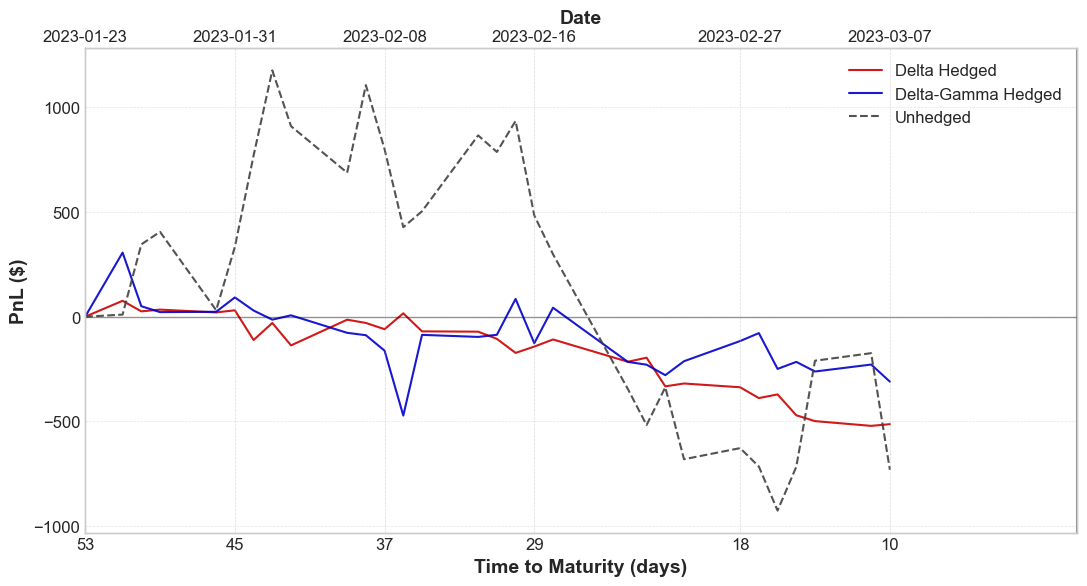

In [652]:
maturity_date = GAMMA_PRIMARY['maturity']

pnl_compare = {
    'Delta Hedged': delta_compare_results['pnl'][:-1],
    'Delta-Gamma Hedged': gamma_compare_results['pnl'],
    'Unhedged': gamma_compare_results['unhedged_pnl']
}

colors = [colors_red[4], colors_blue[4], colors_black[4]]
plot_compare(gamma_compare_results['dates'], pnl_compare, maturity_date, 
             ylabel='PnL ($)', colors=colors, linetypes=['-', '-', '--'])


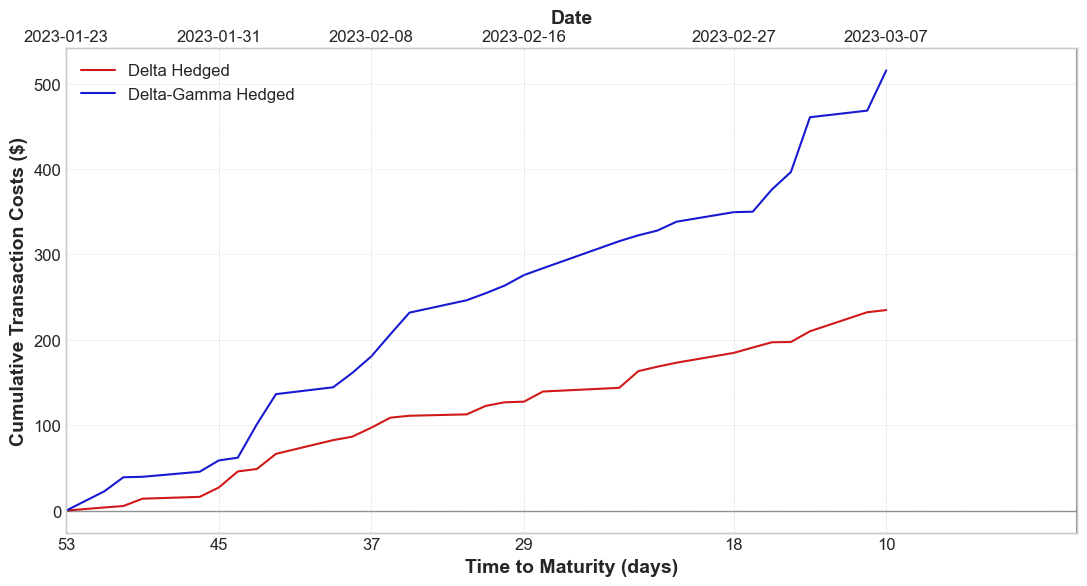

In [653]:
cumulative_tx = {
    'Delta Hedged': delta_compare_results['cumulative_transaction_cost'][:-1],
    'Delta-Gamma Hedged': gamma_compare_results['cumulative_transaction_cost']
}

colors = [colors_red[4], colors_blue[4]]
plot_compare(gamma_compare_results['dates'], cumulative_tx, maturity_date, 
             ylabel='Cumulative Transaction Costs ($)', colors=colors)

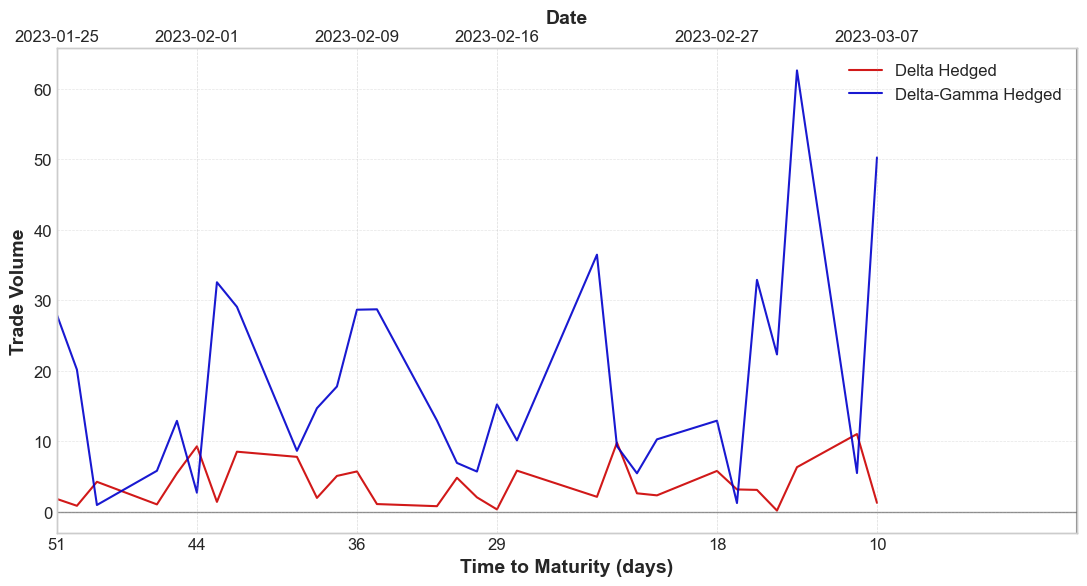

In [654]:
trade_volume = {
    'Delta Hedged': delta_compare_results['trade_volume'][1:-1],
    'Delta-Gamma Hedged': gamma_compare_results['trade_volume'][1:]
}

colors = [colors_red[4], colors_blue[4]]
plot_compare(gamma_compare_results['dates'][1:], trade_volume, maturity_date, 
             ylabel='Trade Volume', colors=colors)

## All 2023 Deltas

In [658]:
exit_days_before_all = 10
all_delta_config = {
    'risk_free_rate': 0.03,
    'n_options': 100,
    'volatility_mode': 'implied',
    'initial_volatility': 0.2,
    'hedge_frequency': 1,
    'share_transaction_cost': DELTA_SHARE_TX_COST
}

all_delta_results = {}
min_length = float('inf')

for maturity_key, option_info in options_data.items():
    data = option_info['data']
    strike = option_info['strike']
    maturity = option_info['maturity']
    
    exit_date = data['Date'].iloc[-1] - timedelta(days=exit_days_before_all)
    
    results = run_delta_hedge(
        data=data,
        strike=strike,
        config=all_delta_config,
        start_date=None,
        end_date=exit_date
    )
    
    all_delta_results[maturity_key] = results
    min_length = min(min_length, len(results['dates']))

print(f"Minimum length across all strategies: {min_length}")
print(f"Loaded {len(all_delta_results)} delta hedging strategies")


Minimum length across all strategies: 48
Loaded 12 delta hedging strategies


In [659]:
max_length = max(len(results['pnl']) for results in all_delta_results.values())

aligned_pnl = {}

for maturity_key, results in all_delta_results.items():
    pnl = results['pnl']
    
    if len(pnl) < max_length:
        padding = [0] * (max_length - len(pnl))
        aligned_pnl[maturity_key] = padding + list(pnl)
    else:
        aligned_pnl[maturity_key] = list(pnl)

time_to_maturity_axis = list(range(max_length + exit_days_before_all - 1, exit_days_before_all - 1, -1))

print(f"All strategies padded to {max_length} data points")
print(f"Time to maturity range: {time_to_maturity_axis[0]} to {time_to_maturity_axis[-1]} days")
print(f"Exit at {exit_days_before_all} days before maturity")

All strategies padded to 56 data points
Time to maturity range: 65 to 10 days
Exit at 10 days before maturity


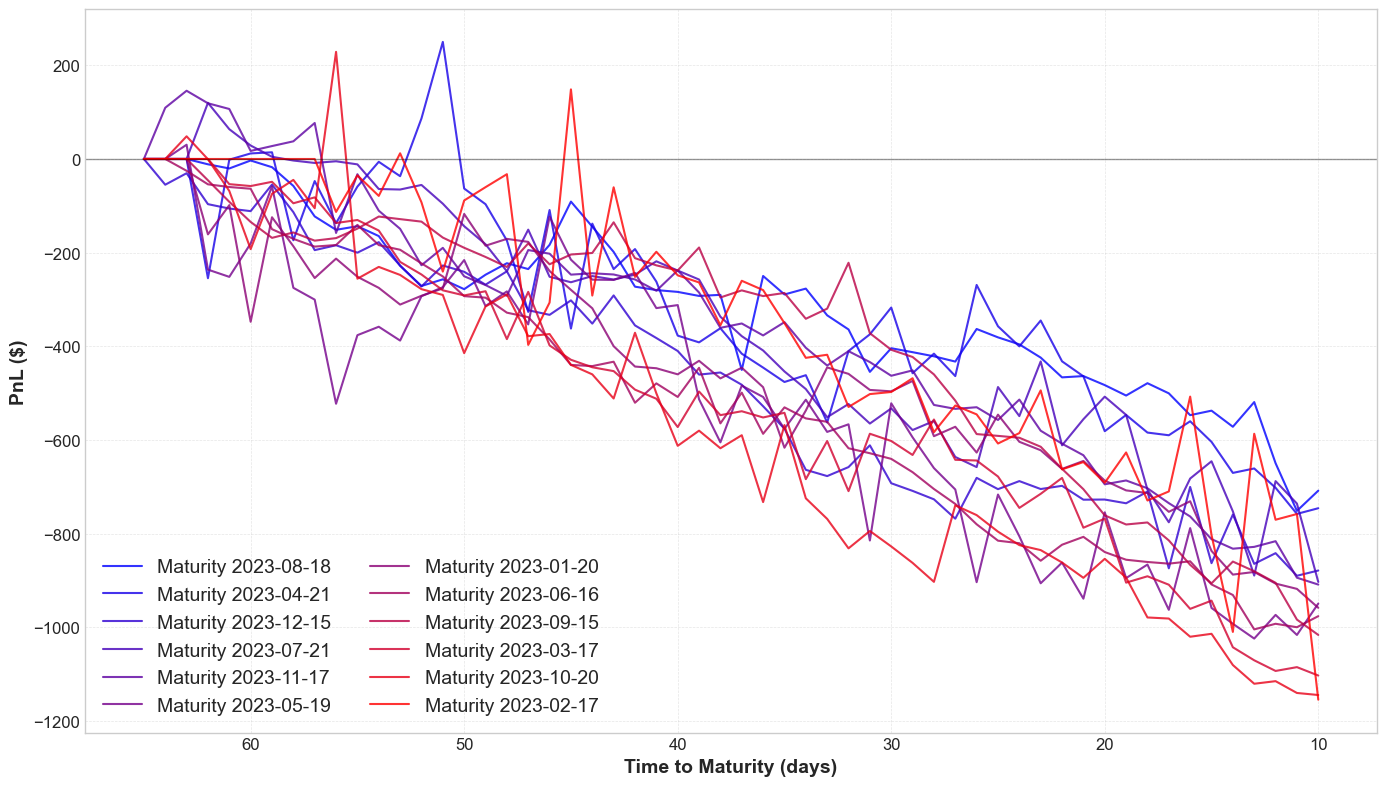

In [660]:
fig, ax = plt.subplots(figsize=(14, 8))

sorted_strategies = sorted(aligned_pnl.items(), key=lambda x: x[1][-1], reverse=True)

n_strategies = len(sorted_strategies)
from matplotlib.colors import LinearSegmentedColormap
colors_gradient = ['#0000ff', '#ff0000']
cmap = LinearSegmentedColormap.from_list('blue_to_red', colors_gradient)
gradient_colors = [cmap(i / (n_strategies - 1)) for i in range(n_strategies)]

for idx, (maturity_key, pnl) in enumerate(sorted_strategies):
    ax.plot(time_to_maturity_axis, pnl, linewidth=1.5, alpha=0.8, 
            color=gradient_colors[idx], label=f'Maturity {maturity_key}')

ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.4)

ax.set_xlabel('Time to Maturity (days)', fontsize=14, fontweight='bold')
ax.set_ylabel('PnL ($)', fontsize=14, fontweight='bold')
#ax.set_title('All 2023 Delta Hedging Strategies - PnL vs Time to Maturity (Sorted by Final PnL)', 
#             fontsize=16, fontweight='bold', pad=20)

ax.invert_xaxis()

ax.legend(loc='best', fontsize=14, ncol=2)
ax.grid(True, alpha=0.5, linestyle='--', linewidth=0.5)
ax.set_facecolor('white')
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()


## All 2023 Gammas

In [662]:
exit_days_before_all_gamma = 10
all_gamma_config = {
    'risk_free_rate': 0.03,
    'n_options': 100,
    'volatility_mode': 'implied',
    'initial_volatility': 0.2,
    'hedge_frequency': 1,
    'share_transaction_cost': GAMMA_SHARE_TX_COST,
    'option_transaction_cost': GAMMA_OPTION_TX_COST
}

all_gamma_results = {}
maturity_keys = sorted(options_data.keys())

for i in range(len(maturity_keys) - 1):
    primary_key = maturity_keys[i]
    hedge_key = maturity_keys[i + 1]
    
    primary_info = options_data[primary_key]
    hedge_info = options_data[hedge_key]
    
    data_A = primary_info['data']
    data_B = hedge_info['data']
    strike_A = primary_info['strike']
    strike_B = hedge_info['strike']
    
    common = get_common_dates(data_A, data_B)
    exit_date = common.iloc[-1] - timedelta(days=exit_days_before_all_gamma)
    
    results = run_gamma_hedge(
        data_A=data_A,
        data_B=data_B,
        strike_A=strike_A,
        strike_B=strike_B,
        config=all_gamma_config,
        start_date=None,
        end_date=exit_date
    )
    
    all_gamma_results[f"{primary_key}+{hedge_key}"] = results

print(f"Loaded {len(all_gamma_results)} gamma hedging strategies")
for key, results in all_gamma_results.items():
    print(f"  {key}: {len(results['dates'])} trading days")


Loaded 11 gamma hedging strategies
  2023-01-20+2023-02-17: 30 trading days
  2023-02-17+2023-03-17: 33 trading days
  2023-03-17+2023-04-21: 30 trading days
  2023-04-21+2023-05-19: 35 trading days
  2023-05-19+2023-06-16: 36 trading days
  2023-06-16+2023-07-21: 31 trading days
  2023-07-21+2023-08-18: 34 trading days
  2023-08-18+2023-09-15: 35 trading days
  2023-09-15+2023-10-20: 30 trading days
  2023-10-20+2023-11-17: 36 trading days
  2023-11-17+2023-12-15: 37 trading days


In [663]:
max_length_gamma = max(len(results['pnl']) for results in all_gamma_results.values())

aligned_pnl_gamma = {}

for strategy_key, results in all_gamma_results.items():
    pnl = results['pnl']
    
    if len(pnl) < max_length_gamma:
        padding = [0] * (max_length_gamma - len(pnl))
        aligned_pnl_gamma[strategy_key] = padding + list(pnl)
    else:
        aligned_pnl_gamma[strategy_key] = list(pnl)

time_to_maturity_axis_gamma = list(range(max_length_gamma + exit_days_before_all_gamma - 1, exit_days_before_all_gamma - 1, -1))

print(f"All gamma strategies padded to {max_length_gamma} data points")
print(f"Time to maturity range: {time_to_maturity_axis_gamma[0]} to {time_to_maturity_axis_gamma[-1]} days")
print(f"Exit at {exit_days_before_all_gamma} days before maturity")


All gamma strategies padded to 37 data points
Time to maturity range: 46 to 10 days
Exit at 10 days before maturity


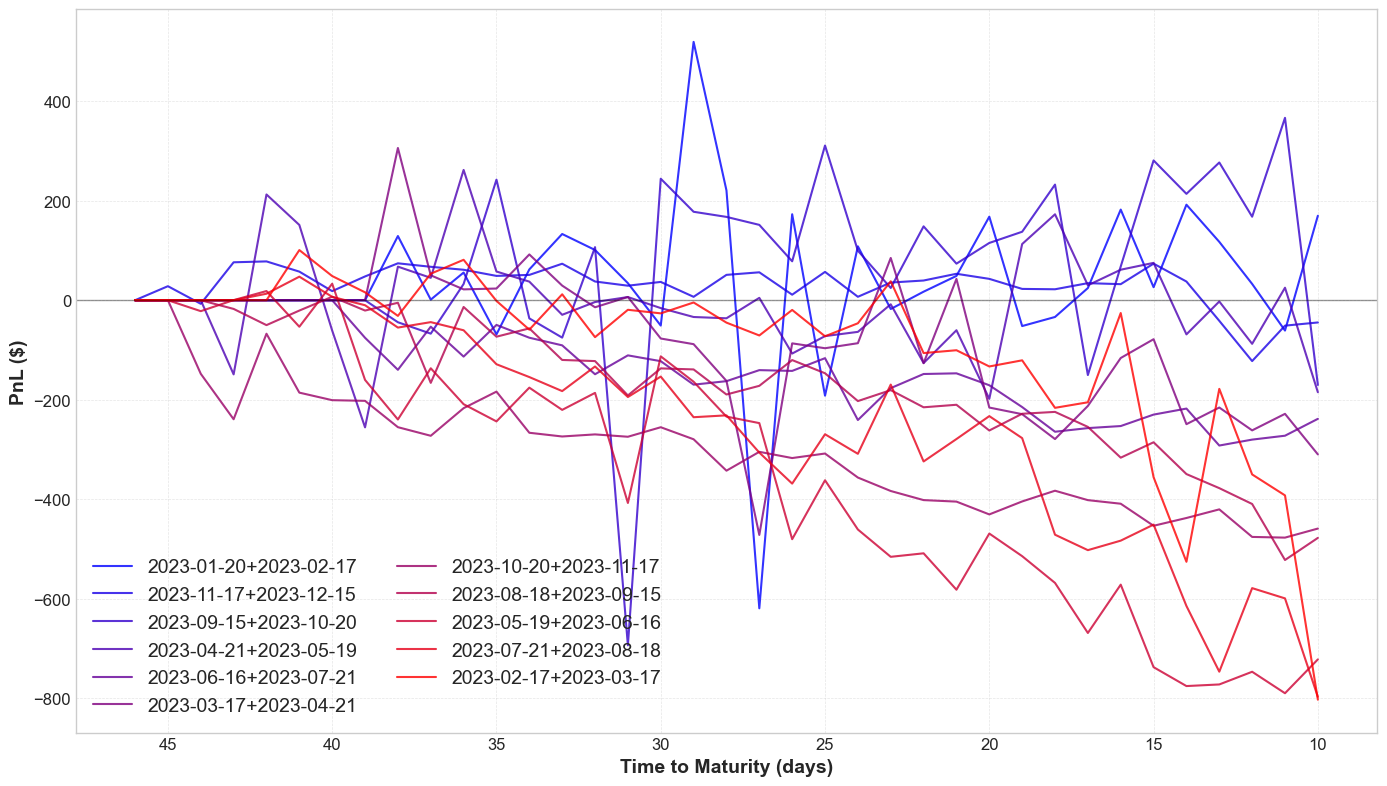

In [664]:
fig, ax = plt.subplots(figsize=(14, 8))

sorted_strategies = sorted(aligned_pnl_gamma.items(), key=lambda x: x[1][-1], reverse=True)

n_strategies = len(sorted_strategies)
from matplotlib.colors import LinearSegmentedColormap
colors_gradient = ['#0000ff', '#ff0000']
cmap = LinearSegmentedColormap.from_list('blue_to_red', colors_gradient)
gradient_colors = [cmap(i / (n_strategies - 1)) for i in range(n_strategies)]

for idx, (strategy_key, pnl) in enumerate(sorted_strategies):
    ax.plot(time_to_maturity_axis_gamma, pnl, linewidth=1.5, alpha=0.8, 
            color=gradient_colors[idx], label=f'{strategy_key}')

ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.4)

ax.set_xlabel('Time to Maturity (days)', fontsize=14, fontweight='bold')
ax.set_ylabel('PnL ($)', fontsize=14, fontweight='bold')
#ax.set_title('', 
#             fontsize=16, fontweight='bold', pad=20)

ax.invert_xaxis()

ax.legend(loc='best', fontsize=14, ncol=2)
ax.grid(True, alpha=0.5, linestyle='--', linewidth=0.5)
ax.set_facecolor('white')
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()


## MSE vs Hedging frequency

In [666]:
hedge_frequencies = range(1, 16)
exit_days_before_freq = 10

avg_normalized_mse_by_freq = []

for freq in hedge_frequencies:
    freq_config = {
        'risk_free_rate': 0.03,
        'n_options': 100,
        'volatility_mode': 'implied',
        'initial_volatility': 0.2,
        'hedge_frequency': freq,
        'share_transaction_cost': 0.0
    }
    
    normalized_mse_values = []
    
    for maturity_key, option_info in options_data.items():
        data = option_info['data']
        strike = option_info['strike']
        
        exit_date = data['Date'].iloc[-1] - timedelta(days=exit_days_before_freq)
        
        results = run_delta_hedge(
            data=data,
            strike=strike,
            config=freq_config,
            start_date=None,
            end_date=exit_date
        )
        
        metrics = calculate_metrics(results, freq_config)
        normalized_mse_values.append(metrics['normalized_mse'])
    
    avg_normalized_mse = np.mean(normalized_mse_values)
    avg_normalized_mse_by_freq.append(avg_normalized_mse)
    
    print(f"Frequency {freq}: Avg Normalized MSE = {avg_normalized_mse:.6f}")

print("\nCompleted hedge frequency analysis for frequencies 1-15 days")


Frequency 1: Avg Normalized MSE = 0.024912
Frequency 2: Avg Normalized MSE = 0.020559
Frequency 2: Avg Normalized MSE = 0.020559
Frequency 3: Avg Normalized MSE = 0.032229
Frequency 3: Avg Normalized MSE = 0.032229
Frequency 4: Avg Normalized MSE = 0.027602
Frequency 4: Avg Normalized MSE = 0.027602
Frequency 5: Avg Normalized MSE = 0.036105
Frequency 5: Avg Normalized MSE = 0.036105
Frequency 6: Avg Normalized MSE = 0.035847
Frequency 6: Avg Normalized MSE = 0.035847
Frequency 7: Avg Normalized MSE = 0.037499
Frequency 7: Avg Normalized MSE = 0.037499
Frequency 8: Avg Normalized MSE = 0.038262
Frequency 8: Avg Normalized MSE = 0.038262
Frequency 9: Avg Normalized MSE = 0.036828
Frequency 9: Avg Normalized MSE = 0.036828
Frequency 10: Avg Normalized MSE = 0.038015
Frequency 10: Avg Normalized MSE = 0.038015
Frequency 11: Avg Normalized MSE = 0.036812
Frequency 11: Avg Normalized MSE = 0.036812
Frequency 12: Avg Normalized MSE = 0.040465
Frequency 12: Avg Normalized MSE = 0.040465
Frequ

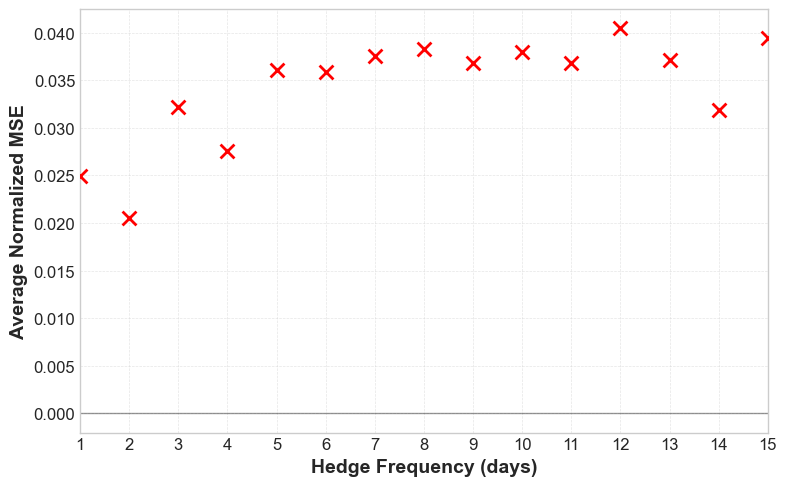

In [667]:
fig, ax = plt.subplots(figsize=(8, 5))

x_data = np.array(list(hedge_frequencies))
y_data = np.array(avg_normalized_mse_by_freq)

ax.scatter(x_data, y_data, s=100, color='red', marker='x', linewidths=2, zorder=5)

ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.4)

ax.set_xlabel('Hedge Frequency (days)', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Normalized MSE', fontsize=14, fontweight='bold')

ax.set_xlim(1, 15)
ax.set_xticks(list(hedge_frequencies))
ax.grid(True, alpha=0.5, linestyle='--', linewidth=0.5)
ax.set_facecolor('white')
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()


## Hedge Frequency vs Trading Volume

In [669]:
avg_total_volume_by_freq = []

for freq in hedge_frequencies:
    freq_config = {
        'risk_free_rate': 0.03,
        'n_options': 100,
        'volatility_mode': 'implied',
        'initial_volatility': 0.2,
        'hedge_frequency': freq,
        'share_transaction_cost': 0.0
    }
    
    total_volume_values = []
    
    for maturity_key, option_info in options_data.items():
        data = option_info['data']
        strike = option_info['strike']
        
        exit_date = data['Date'].iloc[-1] - timedelta(days=exit_days_before_freq)
        
        results = run_delta_hedge(
            data=data,
            strike=strike,
            config=freq_config,
            start_date=None,
            end_date=exit_date
        )
        
        metrics = calculate_metrics(results, freq_config)
        total_volume_values.append(metrics['total_volume'])
    
    avg_total_volume = np.mean(total_volume_values)
    avg_total_volume_by_freq.append(avg_total_volume)
    
    print(f"Frequency {freq}: Avg Total Volume = {avg_total_volume:.2f}")

print("\nCompleted volume analysis for frequencies 1-15 days")


Frequency 1: Avg Total Volume = 277.81
Frequency 2: Avg Total Volume = 215.39
Frequency 2: Avg Total Volume = 215.39
Frequency 3: Avg Total Volume = 169.24
Frequency 3: Avg Total Volume = 169.24
Frequency 4: Avg Total Volume = 162.96
Frequency 4: Avg Total Volume = 162.96
Frequency 5: Avg Total Volume = 142.38
Frequency 5: Avg Total Volume = 142.38
Frequency 6: Avg Total Volume = 137.17
Frequency 6: Avg Total Volume = 137.17
Frequency 7: Avg Total Volume = 130.45
Frequency 7: Avg Total Volume = 130.45
Frequency 8: Avg Total Volume = 123.08
Frequency 8: Avg Total Volume = 123.08
Frequency 9: Avg Total Volume = 120.98
Frequency 9: Avg Total Volume = 120.98
Frequency 10: Avg Total Volume = 121.55
Frequency 10: Avg Total Volume = 121.55
Frequency 11: Avg Total Volume = 111.81
Frequency 11: Avg Total Volume = 111.81
Frequency 12: Avg Total Volume = 105.88
Frequency 12: Avg Total Volume = 105.88
Frequency 13: Avg Total Volume = 110.95
Frequency 13: Avg Total Volume = 110.95
Frequency 14: Avg

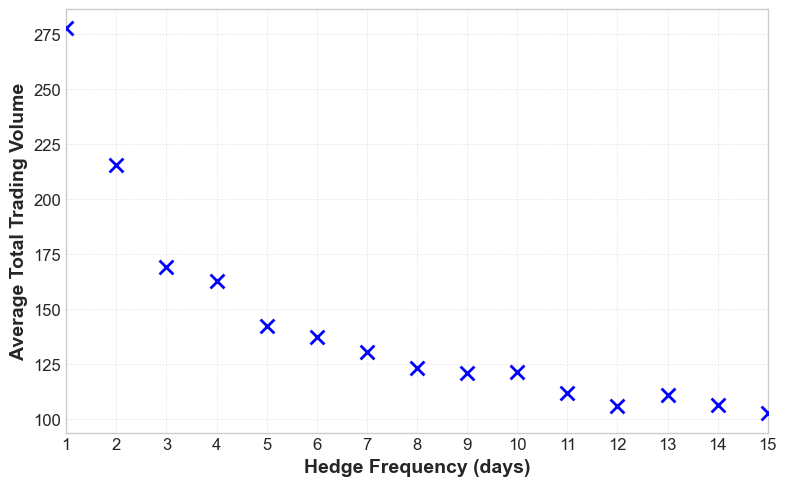

In [670]:
fig, ax = plt.subplots(figsize=(8, 5))

x_data = np.array(list(hedge_frequencies))
y_data = np.array(avg_total_volume_by_freq)

ax.scatter(x_data, y_data, s=100, color='blue', marker='x', linewidths=2, zorder=5)

ax.set_xlabel('Hedge Frequency (days)', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Total Trading Volume', fontsize=14, fontweight='bold')

ax.set_xlim(1, 15)
ax.set_xticks(list(hedge_frequencies))
ax.grid(True, alpha=0.5, linestyle='--', linewidth=0.5)
ax.set_facecolor('white')
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()


In [671]:
spy = yf.Ticker("SPY")
spy_2023 = spy.history(start='2023-01-01', end='2023-12-31')

print(f"SPY data for 2023: {len(spy_2023)} trading days")
print(f"Date range: {spy_2023.index[0].date()} to {spy_2023.index[-1].date()}")
print(f"Price range: ${spy_2023['Close'].min():.2f} to ${spy_2023['Close'].max():.2f}")


SPY data for 2023: 250 trading days
Date range: 2023-01-03 to 2023-12-29
Price range: $365.76 to $466.56


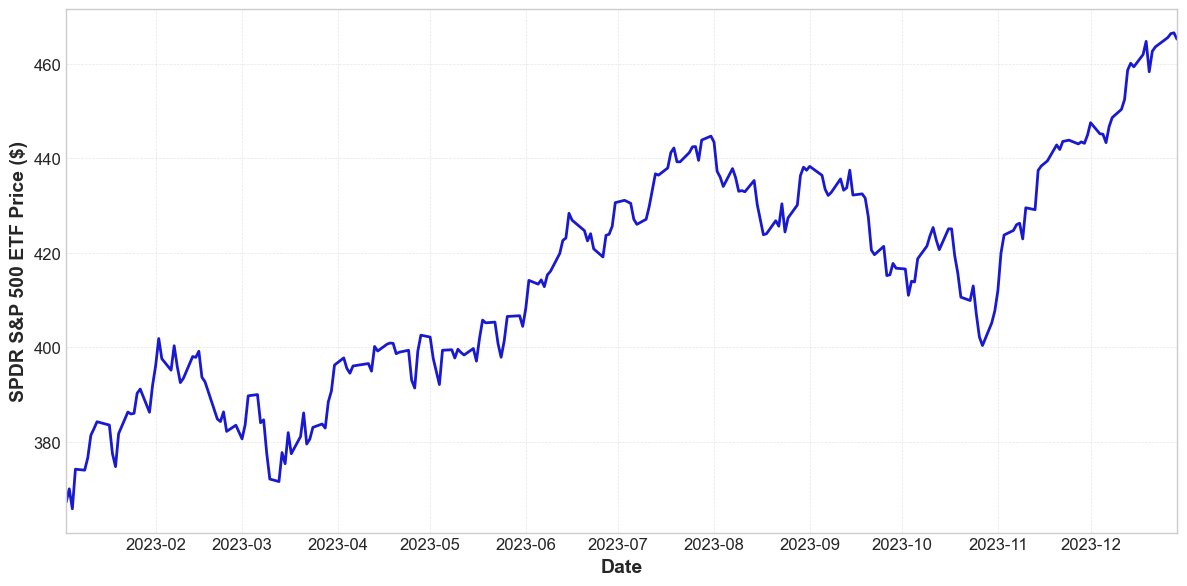

In [676]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(spy_2023.index, spy_2023['Close'], linewidth=2, color=colors_blue[4], alpha=0.9)

ax.set_xlabel('Date', fontsize=14, fontweight='bold')
ax.set_ylabel('SPDR S&P 500 ETF Price ($)', fontsize=14, fontweight='bold')

ax.set_xlim(spy_2023.index[0], spy_2023.index[-1])

ax.grid(True, alpha=0.5, linestyle='--', linewidth=0.5)
ax.set_facecolor('white')
ax.tick_params(axis='both', labelsize=12)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
